In [1]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import seaborn as sns
import pickle
from matplotlib.colors import ListedColormap

In [2]:
### nice plots

import matplotlib as matp

matp.rcParams['mathtext.fontset'] = 'stix'
matp.rcParams['font.family'] = 'STIXGeneral'
markers = ["^", "o", "s"]

colormap = plt.cm.viridis.reversed()
discr_colors = ListedColormap(colormap(np.linspace(0, 1, 3))) 

## Read data for analysis

In [3]:
### MNPP

class Datas():
    def __init__(self, bits_idx_list, vseed_list, n_temp_scalers, M_strats, n_eta_runs, n_samples_SA = 128):
        Ps = np.arange(2,15)
        Ns = 8*Ps
        self.Ns = Ns[bits_idx_list]
        self.Ps = Ps[bits_idx_list]
        self.bits = Ns[bits_idx_list] * Ps[bits_idx_list]
        self.M_strategies = M_strats # index: 0->"feasibility", 1->"optimality"
        self.temperature_scalers = [1, 10, 100]
        self.SA_samples = 128

        self.M_star = np.ndarray((len(bits_idx_list), len(vseed_list), n_temp_scalers, len(M_strats), n_eta_runs))
        self.M_L1 = np.ndarray((len(bits_idx_list), len(vseed_list), n_temp_scalers, len(M_strats), n_eta_runs))
        self.eta_required = np.ndarray((len(bits_idx_list), len(vseed_list), n_temp_scalers, len(M_strats), n_eta_runs))
        self.eta_guaranteed = np.ndarray((len(bits_idx_list), len(vseed_list), n_temp_scalers, len(M_strats), n_eta_runs))
        self.eta_effective = np.ndarray((len(bits_idx_list), len(vseed_list), n_temp_scalers, len(M_strats), n_eta_runs))
        self.temperature = np.ndarray((len(bits_idx_list), len(vseed_list), n_temp_scalers, 2)) # last index: 0->initial, 1->final
        self.E_f = np.ndarray((len(bits_idx_list), len(vseed_list)))


## Dataset 
Ps = np.arange(2,15)
Ns = 8*Ps
n_vseeds = 4
runs = 128
vseeds = np.array([42, 43, 44, 45])



N_idxs = np.arange(8)
n_temp_scalers = 3
M_strategies = ["feasibility", "optimality"]
n_eta_runs = 3
data = Datas(N_idxs, vseeds, n_temp_scalers, M_strategies, n_eta_runs)

directory = "../data/SA_NPP/"

for N_idx in N_idxs: # if N_idxs start from 0. Else, write "for N_idx_idx, N_idx in enumerate(N_idxs):"
    filename = directory + f"results-N={Ns[N_idx]}_P={Ps[N_idx]}.txt"
    file = open(filename, "rb")
    D = pickle.load(file)
    file.close()

    assert len(D.keys()) == len(vseeds)
    for seed_idx, seed in enumerate(D):
        data.E_f[N_idx, seed_idx] = D[seed]["E_f"]

        assert len(D[seed].keys()) == n_temp_scalers + 1 # the +1 is for E_f
        for temp_idx, temp_scaler in enumerate(list(D[seed])[1:]):
            data.temperature[N_idx, seed_idx, temp_idx, 0] = D[seed][temp_scaler]["temp_initial"]
            data.temperature[N_idx, seed_idx, temp_idx, 1] = D[seed][temp_scaler]["temp_final"]

            assert len(D[seed][temp_scaler].keys()) == len(M_strategies) + 2  # the +2 is for temp_initial and temp_final
            for M_strat_idx, M_strat in enumerate(list(D[seed][temp_scaler])[2:]):
                assert len(D[seed][temp_scaler][M_strat].keys()) == n_eta_runs
                for eta_run_idx, eta_req in enumerate(D[seed][temp_scaler][M_strat]):
                    data.M_star[N_idx, seed_idx, temp_idx, M_strat_idx, eta_run_idx] = D[seed][temp_scaler][M_strat][eta_req]["M_star"]
                    data.M_L1[N_idx, seed_idx, temp_idx, M_strat_idx, eta_run_idx] = D[seed][temp_scaler][M_strat][eta_req]["M_L1"]
                    data.eta_required[N_idx, seed_idx, temp_idx, M_strat_idx, eta_run_idx] = D[seed][temp_scaler][M_strat][eta_req]["eta_required"]
                    data.eta_guaranteed[N_idx, seed_idx, temp_idx, M_strat_idx, eta_run_idx] = D[seed][temp_scaler][M_strat][eta_req]["eta_guaranteed"]
                    data.eta_effective[N_idx, seed_idx, temp_idx, M_strat_idx, eta_run_idx] = D[seed][temp_scaler][M_strat][eta_req]["eta_effective"]


data_MNPP = data

In [4]:
## TSP case

colors = sns.color_palette("Paired", 12)
cases_names = {'38': ['ftv38'], '33': ['ftv33'], '42': ['dantzig42', 'swiss42'], '48': ['ry48p', 'hk48', 'gr48', 'att48'], '44': ['ftv44'], '43': ['p43'], '17': ['br17', 'gr17'], '53': ['ft53'], '21': ['gr21'], '55': ['ftv55'], '58': ['brazil58'], '14': ['burma14'], '29': ['bayg29', 'bays29'], '16': ['ulysses16'], '35': ['ftv35'], '47': ['ftv47'], '52': ['berlin52'], '22': ['ulysses22'], '26': ['fri26']}
N_cities =  list(cases_names.keys())
for i in range(len(N_cities)):
    N_cities[i] = int(N_cities[i])
N_cities = np.sort(N_cities)

n_vseeds = 1
runs = 128
vseeds = np.array([42])


class Datas():
    def __init__(self, bits_idx_list, vseed_list, n_temp_scalers, M_strats, n_eta_runs, n_samples_SA = 128):
        self.Nc = N_cities[bits_idx_list]
        self.bits = N_cities[bits_idx_list]**2
        self.M_strategies = M_strats # index: 0->"feasibility", 1->"optimality"
        self.temperature_scalers = np.array([1, 10, 100])
        self.SA_samples = 128

        self.M_star = np.ndarray((len(bits_idx_list), len(vseed_list), n_temp_scalers, len(M_strats), n_eta_runs))
        self.M_L1 = np.ndarray((len(bits_idx_list), len(vseed_list), n_temp_scalers, len(M_strats), n_eta_runs))
        self.eta_required = np.ndarray((len(bits_idx_list), len(vseed_list), n_temp_scalers, len(M_strats), n_eta_runs))
        self.eta_guaranteed = np.ndarray((len(bits_idx_list), len(vseed_list), n_temp_scalers, len(M_strats), n_eta_runs))
        self.eta_effective = np.ndarray((len(bits_idx_list), len(vseed_list), n_temp_scalers, len(M_strats), n_eta_runs))
        self.temperature = np.ndarray((len(bits_idx_list), len(vseed_list), n_temp_scalers, 2)) # last index: 0->initial, 1->final
        self.E_f = np.ndarray((len(bits_idx_list), len(vseed_list)))


N_idxs = np.arange(6) # Use this to keep the 441 bits instance
# N_idxs = np.array([0,1,2,4,5]) # Use this to cut out the 441 bits instance
n_temp_scalers = 3
M_strategies = ["feasibility", "optimality"]
n_eta_runs = 3
data = Datas(N_idxs, vseeds, n_temp_scalers, M_strategies, n_eta_runs)

directory = "../data/SA_TSP_case/"

for N_idx in N_idxs:
    Nc = N_cities[N_idx]
    filename = directory + f"results-{cases_names[str(Nc)][0]}.txt"
    file = open(filename, "rb")
    D = pickle.load(file)
    file.close()

    assert len(D.keys()) == len(vseeds)
    for seed_idx, seed in enumerate(D):
        data.E_f[N_idx, seed_idx] = D[seed]["E_f"]

        assert len(D[seed].keys()) == n_temp_scalers + 1 # the +1 is for E_f
        for temp_idx, temp_scaler in enumerate(list(D[seed])[1:]):
            data.temperature[N_idx, seed_idx, temp_idx, 0] = D[seed][temp_scaler]["temp_initial"]
            data.temperature[N_idx, seed_idx, temp_idx, 1] = D[seed][temp_scaler]["temp_final"]

            assert len(D[seed][temp_scaler].keys()) == len(M_strategies) + 2  # the +2 is for temp_initial and temp_final
            for M_strat_idx, M_strat in enumerate(list(D[seed][temp_scaler])[2:]):
                assert len(D[seed][temp_scaler][M_strat].keys()) == n_eta_runs
                for eta_run_idx, eta_req in enumerate(D[seed][temp_scaler][M_strat]):
                    data.M_star[N_idx, seed_idx, temp_idx, M_strat_idx, eta_run_idx] = D[seed][temp_scaler][M_strat][eta_req]["M_star"]
                    data.M_L1[N_idx, seed_idx, temp_idx, M_strat_idx, eta_run_idx] = D[seed][temp_scaler][M_strat][eta_req]["M_L1"]
                    data.eta_required[N_idx, seed_idx, temp_idx, M_strat_idx, eta_run_idx] = D[seed][temp_scaler][M_strat][eta_req]["eta_required"]
                    data.eta_guaranteed[N_idx, seed_idx, temp_idx, M_strat_idx, eta_run_idx] = D[seed][temp_scaler][M_strat][eta_req]["eta_guaranteed"]
                    data.eta_effective[N_idx, seed_idx, temp_idx, M_strat_idx, eta_run_idx] = D[seed][temp_scaler][M_strat][eta_req]["eta_effective"]


data_TSP_case = data

In [5]:
## TSP circle 

colors = sns.color_palette("Paired", 12)

N_cities =  np.arange(4, 65, 2)
n_vseeds = 1
runs = 128
vseeds = np.array([42])


class Datas():
    def __init__(self, bits_idx_list, vseed_list, n_temp_scalers, M_strats, n_eta_runs, n_samples_SA = 128):
        self.Nc = N_cities[bits_idx_list]
        self.bits = N_cities[bits_idx_list]**2
        self.M_strategies = M_strats # index: 0->"feasibility", 1->"optimality"
        self.temperature_scalers = [1, 10, 100]
        self.SA_samples = 128

        self.M_star = np.ndarray((len(bits_idx_list), len(vseed_list), n_temp_scalers, len(M_strats), n_eta_runs))
        self.M_L1 = np.ndarray((len(bits_idx_list), len(vseed_list), n_temp_scalers, len(M_strats), n_eta_runs))
        self.eta_required = np.ndarray((len(bits_idx_list), len(vseed_list), n_temp_scalers, len(M_strats), n_eta_runs))
        self.eta_guaranteed = np.ndarray((len(bits_idx_list), len(vseed_list), n_temp_scalers, len(M_strats), n_eta_runs))
        self.eta_effective = np.ndarray((len(bits_idx_list), len(vseed_list), n_temp_scalers, len(M_strats), n_eta_runs))
        self.temperature = np.ndarray((len(bits_idx_list), len(vseed_list), n_temp_scalers, 2)) # last index: 0->initial, 1->final
        self.E_f = np.ndarray((len(bits_idx_list), len(vseed_list)))


N_idxs = np.arange(12)
n_temp_scalers = 3
M_strategies = ["feasibility", "optimality"]
n_eta_runs = 3
data = Datas(N_idxs, vseeds, n_temp_scalers, M_strategies, n_eta_runs)

directory = "../data/SA_TSP_circle/"

for N_idx in N_idxs: # if N_idxs start from 0. Else, write "for N_idx_idx, N_idx in enumerate(N_idxs):"
    filename = directory + f"results-Nc={N_cities[N_idx]}.txt"
    file = open(filename, "rb")
    D = pickle.load(file)
    file.close()

    assert len(D.keys()) == len(vseeds)
    for seed_idx, seed in enumerate(D):
        data.E_f[N_idx, seed_idx] = D[seed]["E_f"]

        assert len(D[seed].keys()) == n_temp_scalers + 1 # the +1 is for E_f
        for temp_idx, temp_scaler in enumerate(list(D[seed])[1:]):
            data.temperature[N_idx, seed_idx, temp_idx, 0] = D[seed][temp_scaler]["temp_initial"]
            data.temperature[N_idx, seed_idx, temp_idx, 1] = D[seed][temp_scaler]["temp_final"]

            assert len(D[seed][temp_scaler].keys()) == len(M_strategies) + 2  # the +2 is for temp_initial and temp_final
            for M_strat_idx, M_strat in enumerate(list(D[seed][temp_scaler])[2:]):
                assert len(D[seed][temp_scaler][M_strat].keys()) == n_eta_runs
                for eta_run_idx, eta_req in enumerate(D[seed][temp_scaler][M_strat]):
                    data.M_star[N_idx, seed_idx, temp_idx, M_strat_idx, eta_run_idx] = D[seed][temp_scaler][M_strat][eta_req]["M_star"]
                    data.M_L1[N_idx, seed_idx, temp_idx, M_strat_idx, eta_run_idx] = D[seed][temp_scaler][M_strat][eta_req]["M_L1"]
                    data.eta_required[N_idx, seed_idx, temp_idx, M_strat_idx, eta_run_idx] = D[seed][temp_scaler][M_strat][eta_req]["eta_required"]
                    data.eta_guaranteed[N_idx, seed_idx, temp_idx, M_strat_idx, eta_run_idx] = D[seed][temp_scaler][M_strat][eta_req]["eta_guaranteed"]
                    data.eta_effective[N_idx, seed_idx, temp_idx, M_strat_idx, eta_run_idx] = D[seed][temp_scaler][M_strat][eta_req]["eta_effective"]

data_TSP_circle = data


In [6]:
### PO

class Datas():
    def __init__(self, bits_idx_list, n_temp_scalers, M_strats, n_eta_runs):
        N_stocks = np.array([2, 4, 6, 8, 10, 15, 20, 30, 40, 50, 60])
        self.w = 5
        self.directory = "PO_big"
        vseeds = range(42, 343, 100)

        self.Ns = N_stocks[bits_idx_list]
        self.bits = self.Ns[bits_idx_list] * self.w
        self.vseeds = vseeds
        self.n_vseeds = len(vseeds)
        self.M_strategies = M_strats # index: 0->"feasibility", 1->"optimality"
        self.temperature_scalers = [1, 10, 100]
        self.SA_samples = 1000

        self.M_star = np.ndarray((len(bits_idx_list), len(vseeds), n_temp_scalers, len(M_strats), n_eta_runs))
        self.M_L1 = np.ndarray((len(bits_idx_list), len(vseeds), n_temp_scalers, len(M_strats), n_eta_runs))
        self.eta_required = np.ndarray((len(bits_idx_list), len(vseeds), n_temp_scalers, len(M_strats), n_eta_runs))
        self.eta_guaranteed = np.ndarray((len(bits_idx_list), len(vseeds), n_temp_scalers, len(M_strats), n_eta_runs))
        self.eta_effective = np.ndarray((len(bits_idx_list), len(vseeds), n_temp_scalers, len(M_strats), n_eta_runs))
        self.temperature = np.ndarray((len(bits_idx_list), len(vseeds), n_temp_scalers, 2)) # last index: 0->initial, 1->final
        self.E_f = np.ndarray((len(bits_idx_list), len(vseeds)))


# change last_Nidx to extend your dataset as you collect more data

last_Nidx = 8
N_stocks = np.array([2, 4, 6, 8, 10, 15, 20, 30, 40, 50, 60])
N_idxs = np.arange(last_Nidx+1)
n_temp_scalers = 3
M_strategies = ["feasibility", "optimality"]
n_eta_runs = 3
data = Datas(N_idxs, n_temp_scalers, M_strategies, n_eta_runs)

directory = "../data/SA_PO/"

for N_idx in N_idxs: # if N_idxs start from 0. Else, write "for N_idx_idx, N_idx in enumerate(N_idxs):"
    filename = directory + f"results-N={N_stocks[N_idx]}_w={data.w}.txt"
    file = open(filename, "rb")
    D = pickle.load(file)
    file.close()

    assert len(D.keys()) == len(data.vseeds)
    for seed_idx, seed in enumerate(D):
        data.E_f[N_idx, seed_idx] = D[seed]["E_f"]

        assert len(D[seed].keys()) == n_temp_scalers + 1 # the +1 is for E_f
        for temp_idx, temp_scaler in enumerate(list(D[seed])[1:]):
            data.temperature[N_idx, seed_idx, temp_idx, 0] = D[seed][temp_scaler]["temp_initial"]
            data.temperature[N_idx, seed_idx, temp_idx, 1] = D[seed][temp_scaler]["temp_final"]

            assert len(D[seed][temp_scaler].keys()) == len(M_strategies) + 2  # the +2 is for temperature final and initial
            for M_strat_idx, M_strat in enumerate(list(D[seed][temp_scaler])[2:]):
                assert len(D[seed][temp_scaler][M_strat].keys()) == n_eta_runs
                for eta_run_idx, eta_req in enumerate(D[seed][temp_scaler][M_strat]):
                    data.M_star[N_idx, seed_idx, temp_idx, M_strat_idx, eta_run_idx] = D[seed][temp_scaler][M_strat][eta_req]["M_star"]
                    data.M_L1[N_idx, seed_idx, temp_idx, M_strat_idx, eta_run_idx] = D[seed][temp_scaler][M_strat][eta_req]["M_L1"]
                    data.eta_required[N_idx, seed_idx, temp_idx, M_strat_idx, eta_run_idx] = D[seed][temp_scaler][M_strat][eta_req]["eta_required"]
                    data.eta_guaranteed[N_idx, seed_idx, temp_idx, M_strat_idx, eta_run_idx] = D[seed][temp_scaler][M_strat][eta_req]["eta_guaranteed"]
                    data.eta_effective[N_idx, seed_idx, temp_idx, M_strat_idx, eta_run_idx] = D[seed][temp_scaler][M_strat][eta_req]["eta_effective"]


data_PO = data

## $\eta_{eff}(n_{bits})$

In [24]:
def plot_marker_whiskers(ax, data, indexes, scaler = 1):
    draw_lower_whiskers, draw_upper_whiskers = True, False

    temp_idx, M_strat_idx, eta_run_idx = indexes
    eta_r = data.eta_required[:, 0, temp_idx, M_strat_idx, eta_run_idx]
    y = np.mean( data.eta_effective[:, :, temp_idx, M_strat_idx, eta_run_idx], axis = 1)
    ax.plot(data.bits, y, linestyle="None", marker = markers[temp_idx], markersize = 5, color = discr_colors.colors[eta_run_idx], markeredgecolor="black")

    # compute where to draw whiskers
    condition_eff =  y  <  eta_r
    condition_gua =  np.mean(data.eta_guaranteed[:, :, temp_idx, M_strat_idx, eta_run_idx], axis = 1)  <  eta_r
    mask_whisk = np.logical_and(condition_gua, condition_eff)
    # compute whiskers lengths from eta_guaranteed
    whisk = y[mask_whisk] - np.mean(data.eta_guaranteed[:, :, temp_idx, M_strat_idx, eta_run_idx], axis = 1)[mask_whisk]
    whisk_down = np.where(whisk > 0, whisk, 0)
    whisk_up = np.where(whisk < 0, -whisk, 0)

    capsize = 20/scaler
    cap_thickness = 1.5    
    # draw only lower whiskers manually
    if draw_lower_whiskers:
        for xi, yi, yd in zip(data.bits[mask_whisk], y[mask_whisk], whisk_down):
            ax.vlines(xi, yi - yd, yi, color=discr_colors.colors[eta_run_idx], lw=cap_thickness)
            ax.hlines(yi - yd, xi - capsize, xi + capsize, color=discr_colors.colors[eta_run_idx], lw=cap_thickness)
    # draw only upper whiskers manually
    if draw_upper_whiskers:
        for xi, yi, yd in zip(data.bits[mask_whisk], y[mask_whisk], whisk_up):
            ax.vlines(xi, yi, yi + yd, color=discr_colors.colors[eta_run_idx], lw=cap_thickness)
            ax.hlines(yi + yd, xi - capsize, xi + capsize, color=discr_colors.colors[eta_run_idx], lw=cap_thickness)
    return


def plot_marker_whiskers_rare(ax, data, indexes):
    draw_lower_whiskers, draw_upper_whiskers = True, False

    xs = data.bits[to_plot]
    indexes = temp_idx, M_strat_idx, eta_run_idx
    eta_r = data.eta_required[to_plot, 0, temp_idx, M_strat_idx, eta_run_idx]
    y = np.mean( data.eta_effective[to_plot, :, temp_idx, M_strat_idx, eta_run_idx], axis = 1)
    ax.plot(xs, y, linestyle="None", marker = markers[temp_idx], markersize = 5, color = discr_colors.colors[eta_run_idx], markeredgecolor="black")

    # compute where to draw whiskers
    condition_eff =  y  <  eta_r
    condition_gua =  np.mean(data.eta_guaranteed[to_plot, :, temp_idx, M_strat_idx, eta_run_idx], axis = 1)  <  eta_r
    mask_whisk = np.logical_and(condition_gua, condition_eff)
    # compute whiskers lengths from eta_guaranteed
    whisk = y[mask_whisk] - np.mean(data.eta_guaranteed[to_plot, :, temp_idx, M_strat_idx, eta_run_idx], axis = 1)[mask_whisk]
    whisk_down = np.where(whisk > 0, whisk, 0)
    whisk_up = np.where(whisk < 0, -whisk, 0)

    capsize = 30
    cap_thickness = 1.5    
    # draw only lower whiskers manually
    if draw_lower_whiskers:
        for xi, yi, yd in zip(xs[mask_whisk], y[mask_whisk], whisk_down):
            ax.vlines(xi, yi - yd, yi, color=discr_colors.colors[eta_run_idx], lw=cap_thickness)
            ax.hlines(yi - yd, xi - capsize, xi + capsize, color=discr_colors.colors[eta_run_idx], lw=cap_thickness)
    # draw only upper whiskers manually
    if draw_upper_whiskers:
        for xi, yi, yd in zip(xs[mask_whisk], y[mask_whisk], whisk_up):
            ax.vlines(xi, yi, yi + yd, color=discr_colors.colors[eta_run_idx], lw=cap_thickness)
            ax.hlines(yi + yd, xi - capsize, xi + capsize, color=discr_colors.colors[eta_run_idx], lw=cap_thickness)
    return

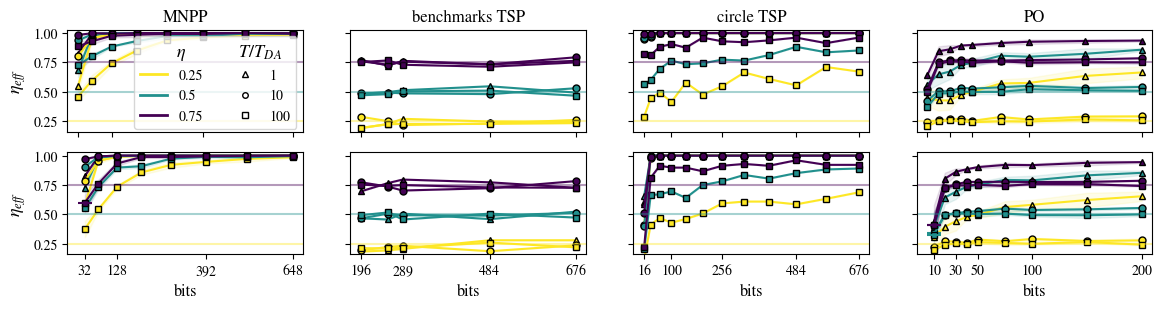

In [25]:
markers = ["^", "o", "s"]
colormap = plt.cm.viridis.reversed()
discr_colors = ListedColormap(colormap(np.linspace(0, 1, 3)))

scaler = 2 # with scaler = 2, the sizes below refer to (half the) pt
size_ticks = 5*scaler
size_label = 6.5*scaler
size_labelx = size_label*.9
size_title = 6*scaler
size_marker = 2*scaler

fig = plt.figure(figsize=(7*scaler,1.46*scaler))

for M_strat_idx in [0,1]:
    ax = fig.add_subplot(2,4, 1 + M_strat_idx*4)
    ax.set_ylabel(r'$\eta_{eff}$', fontsize = size_label)
    ax.set_yticks([.25, .5, .75, 1])
    ax.set_xticks(data_MNPP.bits[[0, 2, 5, 7]])
    if M_strat_idx == 0:
        ax.tick_params(axis='x', labelbottom=False)
    else:
        ax.tick_params(axis='x', labelsize=size_ticks)
    ax.tick_params(axis='y', labelsize=size_ticks) 
    ax.set_ylim(.16, 1.03)
    for temp_idx in range(n_temp_scalers):
        for eta_run_idx in np.arange(n_eta_runs):
            y = np.mean( data_MNPP.eta_effective[:, :, temp_idx, M_strat_idx, eta_run_idx], axis = 1)
            y_std = np.std( data_MNPP.eta_effective[:, :, temp_idx, M_strat_idx, eta_run_idx], axis = 1)
            # lines and shades
            ax.plot(data_MNPP.bits, y, "-", color = discr_colors.colors[eta_run_idx],
                            label=str(data_MNPP.eta_required[0, 0, 0, 0, eta_run_idx]) + f" ; {data_MNPP.temperature_scalers[temp_idx]}")
            ax.fill_between(data_MNPP.bits, y - y_std, y + y_std, color = discr_colors.colors[eta_run_idx], alpha=.1)
            # dots 
            plot_marker_whiskers(ax, data_MNPP, (temp_idx, M_strat_idx, eta_run_idx))    
    if M_strat_idx == 0:
        ax.set_title("MNPP", fontsize = size_title)
        # ---- Concise legend ----
        eta_handles = [Line2D([0], [0], color=c, lw=2, label=f'{eta}') for c, eta in zip(discr_colors.colors, data.eta_required[0,0,0,0])]
        temp_handles = [Line2D([0], [0], color="w", markersize = size_marker,  markeredgecolor = "k", marker=m, lw=0, label=T) for m, T in zip(markers, data.temperature_scalers)]
        all_handles = eta_handles + temp_handles
        all_labels  = [h.get_label() for h in all_handles]
        ax.legend(handles=all_handles, labels=all_labels, title=r"      $\eta$            $T/T_{DA}$", title_fontsize=size_label, fontsize=size_ticks, loc="best", ncol=2)
        # --------
    else:
        ax.set_xlabel(r'bits', fontsize = size_labelx)
    eta_req_tmp = [.25, .5, .75]
    for i in range(len(eta_req_tmp)):
        ax.axhline(eta_req_tmp[i], color = discr_colors.colors[i], alpha = 0.4)


to_plot = [0,1,2,4,5]
for M_strat_idx in [0,1]:
    ax = fig.add_subplot(2,4, 2 + M_strat_idx*4)
    ax.set_yticks([.25, .5, .75, 1])
    ax.set_xticks(data_TSP_case.bits[[0,2,4,5]])
    if M_strat_idx == 0:
        ax.tick_params(axis='x', labelbottom=False)
    else:
        ax.tick_params(axis='x', labelsize=size_ticks)
    ax.tick_params(axis='y', labelleft=False) 
    ax.set_ylim(.16, 1.03)
    for temp_idx in range(n_temp_scalers):
        for eta_run_idx in np.arange(n_eta_runs):
            y = np.mean( data_TSP_case.eta_effective[to_plot, :, temp_idx, M_strat_idx, eta_run_idx], axis = 1)
            y_std = np.std( data_TSP_case.eta_effective[to_plot, :, temp_idx, M_strat_idx, eta_run_idx], axis = 1)
            # lines and shades
            ax.plot(data_TSP_case.bits[to_plot], y, "-", color = discr_colors.colors[eta_run_idx],
                            label=str(data_TSP_case.eta_required[0, 0, 0, 0, eta_run_idx]) + f" ; {data_TSP_case.temperature_scalers[temp_idx]}")
            ax.fill_between(data_TSP_case.bits[to_plot], y - y_std, y + y_std, color = discr_colors.colors[eta_run_idx], alpha=.1)
            # dots 
            plot_marker_whiskers_rare(ax, data_TSP_case, (temp_idx, M_strat_idx, eta_run_idx))    
    if M_strat_idx == 0:
        ax.set_title("benchmarks TSP", fontsize = size_title)
    else:
        ax.set_xlabel(r'bits', fontsize = size_labelx)
    eta_req_tmp = [.25, .5, .75]
    for i in range(len(eta_req_tmp)):
        ax.axhline(eta_req_tmp[i], color = discr_colors.colors[i], alpha = 0.4)



for M_strat_idx in [0,1]:
    ax = fig.add_subplot(2,4, 3 + M_strat_idx*4)
    ax.set_yticks([.25, .5, .75, 1])
    ax.set_xticks(data_TSP_circle.bits[[0, 3, 6, 9, 11]])
    if M_strat_idx == 0:
        ax.tick_params(axis='x', labelbottom=False)
    else:
        ax.tick_params(axis='x', labelsize=size_ticks)
    ax.tick_params(axis='y', labelleft=False) 
    ax.set_ylim(.16, 1.03)
    for temp_idx in range(n_temp_scalers):
        for eta_run_idx in np.arange(n_eta_runs):
            y = np.mean( data_TSP_circle.eta_effective[:, :, temp_idx, M_strat_idx, eta_run_idx], axis = 1)
            y_std = np.std( data_TSP_circle.eta_effective[:, :, temp_idx, M_strat_idx, eta_run_idx], axis = 1)
            # lines and shades
            ax.plot(data_TSP_circle.bits, y, "-", color = discr_colors.colors[eta_run_idx],
                            label=str(data_TSP_circle.eta_required[0, 0, 0, 0, eta_run_idx]) + f" ; {data_TSP_circle.temperature_scalers[temp_idx]}")
            ax.fill_between(data_TSP_circle.bits, y - y_std, y + y_std, color = discr_colors.colors[eta_run_idx], alpha=.1)
            # dots 
            plot_marker_whiskers(ax, data_TSP_circle, (temp_idx, M_strat_idx, eta_run_idx))  
    if M_strat_idx == 0:
        ax.set_title("circle TSP", fontsize = size_title)
    else:
        ax.set_xlabel(r'bits', fontsize = size_labelx)
    eta_req_tmp = [.25, .5, .75]
    for i in range(len(eta_req_tmp)):
        ax.axhline(eta_req_tmp[i], color = discr_colors.colors[i], alpha = 0.4)



for M_strat_idx in [0,1]:
    ax = fig.add_subplot(2,4, 4 + M_strat_idx*4)
    ax.set_yticks([.25, .5, .75, 1])
    ax.set_xticks(data_PO.bits[::2])
    if M_strat_idx == 0:
        ax.tick_params(axis='x', labelbottom=False)
    else:
        ax.tick_params(axis='x', labelsize=size_ticks)
    ax.tick_params(axis='y', labelleft=False) 
    ax.set_ylim(.16, 1.03)
    for temp_idx in range(n_temp_scalers):
        for eta_run_idx in np.arange(n_eta_runs):
            y = np.mean( data_PO.eta_effective[:, :, temp_idx, M_strat_idx, eta_run_idx], axis = 1)
            y_std = np.std( data_PO.eta_effective[:, :, temp_idx, M_strat_idx, eta_run_idx], axis = 1)
            # lines and shades
            ax.plot(data_PO.bits, y, "-", color = discr_colors.colors[eta_run_idx],
                            label=str(data_PO.eta_required[0, 0, 0, 0, eta_run_idx]) + f" ; {data_PO.temperature_scalers[temp_idx]}")
            ax.fill_between(data_PO.bits, y - y_std, y + y_std, color = discr_colors.colors[eta_run_idx], alpha=.1)
            # dots 
            plot_marker_whiskers(ax, data_PO, (temp_idx, M_strat_idx, eta_run_idx), scaler = 3.25)    
    if M_strat_idx == 0:
        ax.set_title("PO", fontsize = size_title)
    else:
        ax.set_xlabel(r'bits', fontsize = size_labelx)
    eta_req_tmp = [.25, .5, .75]
    for i in range(len(eta_req_tmp)):
        ax.axhline(eta_req_tmp[i], color = discr_colors.colors[i], alpha = 0.4)

plt.show()

# fig.savefig(f"../plots_paper/eta_eff_big/SA_2.pdf", bbox_inches='tight', format="pdf")